# 02 — Detection floor on the rate sweep (new data)

The sweep was generated to answer one question: **how low can the attacker rate go
before the unsupervised Isolation Forest stops catching it?** That crossover is the
"detection floor" and is the intended research contribution.

This notebook does three things:

1. **Traffic-health diagnostic** — checks whether the *legitimate* background traffic is
   actually alive during the attack window. (It is not — see below. This dominates
   everything that follows.)
2. **Background-vs-attacker contrast** — quantifies how much legit traffic the attacker
   has to hide inside, per rate.
3. **Isolation Forest detection floor** — the actual detection-rate-vs-attacker-rate curve.

The headline result is two-sided, and both sides trace back to the same flaw:

- **IFA detection is flat at ~100% at every rate down to 10 Hz** — no floor is reached.
- **CP detection *does* bend down** (100% at >=20 Hz -> ~90% at 15 Hz -> ~66% at 10 Hz),
  so a floor appears around 12-15 Hz.

But neither curve is trustworthy, because the legitimate consumers go silent ~30 s into
every run (Section 1). During the entire evaluation window the attacker is essentially the
*only* source of traffic, and the model's notion of "normal" is dominated by an idle
network. The IFA floor is hidden (its timeout/NACK signature fires against silence at any
rate); the CP floor is an artifact of comparing a rate outlier to silence rather than to
real traffic. The sweep cannot measure a real floor until the background-traffic bug is
fixed.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = PROJECT_ROOT / "processed"
FIG_D = PROJECT_ROOT / "figures" / "diagnostic"
FIG_F = PROJECT_ROOT / "figures" / "detection"
for d in (FIG_D, FIG_F): d.mkdir(parents=True, exist_ok=True)

full = pd.read_csv(PROC / "full_sweep.csv")
print("full_sweep:", full.shape)
print(full.groupby("scenario").size())
ATTACK_START = 301
RATES = sorted(full.loc[full.scenario!="normal","rate"].dropna().unique().astype(int))
print("rates:", RATES)


full_sweep: (1520674, 26)
scenario
cp        706034
ifa       712810
normal    101830
dtype: int64
rates: [np.int64(10), np.int64(12), np.int64(15), np.int64(20), np.int64(30), np.int64(50), np.int64(100)]


## 1. Traffic-health diagnostic

For the **normal** scenario, sum the interests emitted by the legitimate consumers each
second (averaged over the 5 seeds). If the background were healthy it would sit near
`6 consumers x 10 Hz = 60 interests/s` for the whole 600 s run.

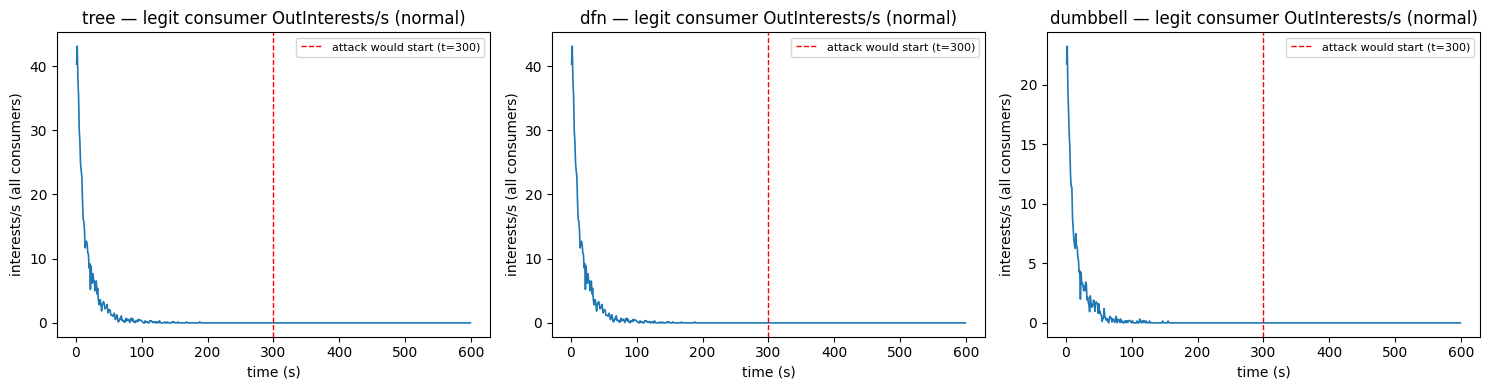

    topo  startup_t_le_30  steady_t_gt_30  attackwin_t_ge_301
    tree       499.230546       97.769437        2.076917e-80
     dfn       499.230546       97.769437        2.076917e-80
dumbbell       252.145001       49.054982       1.784065e-103


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, topo in zip(axes, ["tree","dfn","dumbbell"]):
    nrm = full[(full.topology==topo)&(full.scenario=="normal")&(full.role=="benign_consumer")]
    ts = nrm.groupby("Time")["OutInterests"].sum() / nrm["run"].nunique()
    ax.plot(ts.index, ts.values, lw=1.2)
    ax.axvline(300, color="red", ls="--", lw=1, label="attack would start (t=300)")
    ax.set_title(f"{topo} — legit consumer OutInterests/s (normal)")
    ax.set_xlabel("time (s)"); ax.set_ylabel("interests/s (all consumers)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_D/"fig_legit_traffic_decay.png", dpi=130, bbox_inches="tight")
plt.show()

# quantify: startup (t<=30) vs steady (t>30) and attack-window (t>=301)
rows=[]
for topo in ["tree","dfn","dumbbell"]:
    nrm = full[(full.topology==topo)&(full.scenario=="normal")&(full.role=="benign_consumer")]
    per_run = nrm["run"].nunique()
    rows.append(dict(topo=topo,
        startup_t_le_30=nrm[nrm.Time<=30]["OutInterests"].sum()/per_run,
        steady_t_gt_30 =nrm[nrm.Time>30]["OutInterests"].sum()/per_run,
        attackwin_t_ge_301=nrm[nrm.Time>=301]["OutInterests"].sum()/per_run))
diag = pd.DataFrame(rows)
print(diag.to_string(index=False))


The legitimate traffic is essentially all emitted in the first ~30 seconds and then
collapses to zero. The `ConsumerZipfMandelbrot` catalog (`NumberOfContents=100`) is
exhausted at 10 Hz in ~10 s, after which the consumers stop requesting. **There is no
background traffic during the attack window.**

## 2. Background-vs-attacker contrast during the attack window

For each rate, compare the attacker's interest output to the legitimate background still
present in the attack window (t >= 301). A meaningful detection floor needs the attacker
to be *comparable to* the background; here the background is ~0 at every rate.

In [3]:
rows=[]
for topo in ["tree","dfn","dumbbell"]:
    for atk in ["ifa","cp"]:
        for r in RATES:
            sub = full[(full.topology==topo)&(full.scenario==atk)&(full.rate==r)&(full.Time>=ATTACK_START)]
            if sub.empty: continue
            att = sub[sub.role=="attacker"].groupby(["run"])["OutInterests"].mean().mean()
            leg = sub[sub.role=="benign_consumer"].groupby(["run"])["OutInterests"].mean().mean()
            rows.append(dict(topo=topo, attack=atk, rate=r,
                             attacker_out=round(att,1),
                             legit_out=round(leg,3),
                             contrast=round(att/leg,1) if leg>1e-6 else np.inf))
contrast = pd.DataFrame(rows)
print(contrast.pivot_table(index=["topo","attack"], columns="rate",
      values="legit_out").to_string())
print("\n^ legit consumer interests/s in the attack window — ~0 everywhere.")
contrast.to_csv(PROC/"attack_window_contrast.csv", index=False)


rate             10   12   15   20   30   50   100
topo     attack                                   
dfn      cp      0.0  0.0  0.0  0.0  0.0  0.0  0.0
         ifa     0.0  0.0  0.0  0.0  0.0  0.0  0.0
dumbbell cp      0.0  0.0  0.0  0.0  0.0  0.0  0.0
         ifa     0.0  0.0  0.0  0.0  0.0  0.0  0.0
tree     cp      0.0  0.0  0.0  0.0  0.0  0.0  0.0
         ifa     0.0  0.0  0.0  0.0  0.0  0.0  0.0

^ legit consumer interests/s in the attack window — ~0 everywhere.


## 3. Isolation Forest detection floor

Same detector as the main pipeline: `StandardScaler -> IsolationForest(n_estimators=200,
contamination=0.01, random_state=42)`, trained **only on normal traffic (t <= 200), no
labels**, pooled across topologies (the global model). Anomaly score is the normalized
inverse of `decision_function`; alarm threshold = 70 (== normalized boundary 30).

In [4]:
FEATURES = ["InInterests","OutInterests","InData","cache_hit_ratio","satisfaction_ratio",
            "timeout_ratio","nack_ratio","interest_amp","data_ratio"]
ALARM = 70

train = full[(full.scenario=="normal") & (full.Time<=200)]
pipe = Pipeline([("scaler", StandardScaler()),
                 ("if", IsolationForest(n_estimators=200, contamination=0.01, random_state=42))])
pipe.fit(train[FEATURES])

dfun_train = pipe.decision_function(train[FEATURES])
smin, smax = dfun_train.min(), dfun_train.max()
def anomaly_score(X):
    d = pipe.decision_function(X)
    norm = np.clip(100*(d - smin)/(smax - smin), 0, 100)   # high = normal
    return 100 - norm                                       # high = anomalous

full["anomaly_score"] = anomaly_score(full[FEATURES])
full["alarm"] = full["anomaly_score"] >= ALARM

# held-out normal FPR (t>200 normal)
heldout = full[(full.scenario=="normal") & (full.Time>200)]
print(f"held-out normal FPR: {heldout['alarm'].mean()*100:.2f}%")


held-out normal FPR: 0.00%


In [5]:
# detection rate of attacker nodes per (topo, attack, rate), averaged over seeds
rows=[]
for topo in ["tree","dfn","dumbbell"]:
    for atk in ["ifa","cp"]:
        for r in RATES:
            sub = full[(full.topology==topo)&(full.scenario==atk)&(full.rate==r)&(full.Time>=ATTACK_START)]
            if sub.empty: continue
            att = sub[sub.role=="attacker"]
            ben = sub[sub.role=="benign_consumer"]
            det = att.groupby("run")["alarm"].mean().mean()*100
            fpr = ben.groupby("run")["alarm"].mean().mean()*100 if len(ben) else 0.0
            rows.append(dict(topo=topo, attack=atk, rate=r,
                             detection=round(det,1), benign_fpr=round(fpr,1)))
floor = pd.DataFrame(rows)
floor.to_csv(PROC/"detection_floor.csv", index=False)
print(floor.pivot_table(index=["topo","attack"], columns="rate", values="detection").to_string())


rate               10     12     15     20     30     50     100
topo     attack                                                 
dfn      cp       65.9   67.3   89.9  100.0  100.0  100.0  100.0
         ifa     100.0  100.0  100.0  100.0  100.0  100.0  100.0
dumbbell cp       67.3   72.8   92.5  100.0  100.0  100.0  100.0
         ifa     100.0  100.0  100.0  100.0  100.0  100.0  100.0
tree     cp       65.9   67.3   89.9  100.0  100.0  100.0  100.0
         ifa     100.0  100.0  100.0  100.0  100.0  100.0  100.0


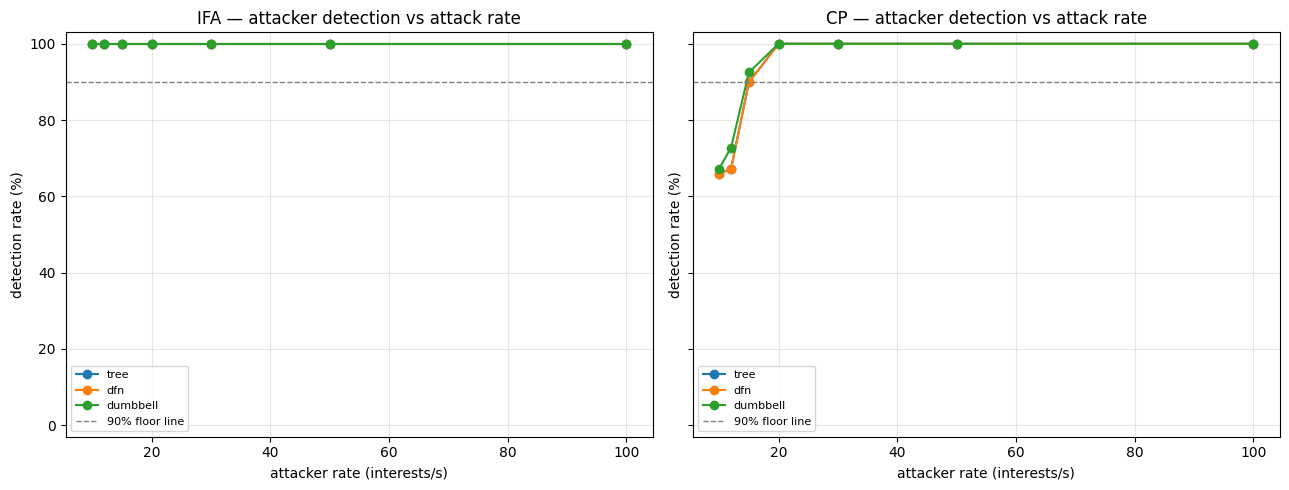

Curve is flat near 100% across all rates -> no floor is reached in this data.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,5), sharey=True)
for ax, atk in zip(axes, ["ifa","cp"]):
    for topo in ["tree","dfn","dumbbell"]:
        d = floor[(floor.attack==atk)&(floor.topo==topo)].sort_values("rate")
        ax.plot(d["rate"], d["detection"], marker="o", label=topo)
    ax.axhline(90, color="gray", ls="--", lw=1, label="90% floor line")
    ax.set_title(f"{atk.upper()} — attacker detection vs attack rate")
    ax.set_xlabel("attacker rate (interests/s)"); ax.set_ylabel("detection rate (%)")
    ax.set_ylim(-3,103); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_F/"fig_detection_floor.png", dpi=130, bbox_inches="tight")
plt.show()
print("Curve is flat near 100% across all rates -> no floor is reached in this data.")


## Verdict

The two attacks behave differently, and the difference is itself diagnostic of the data
problem:

| attack | curve | why |
|---|---|---|
| **IFA** | flat ~100% at every rate (10 -> 100 Hz) | IFA points at a black-hole `/evil`, so its signature is *qualitative* — timeouts, NACKs, zero satisfaction — not just volume. Against a silent network that fires at any rate, so no floor is exposed. |
| **CP**  | 100% at >=20 Hz, ~90% at 15 Hz, ~66% at 10 Hz | CP requests *real* (junk) content that is answered, so its only signal is volume. At low rate it sinks toward the idle/startup baseline and stops being an outlier. |

Both results are **confounded by dead background traffic**:

- The legitimate consumers emit only during the first ~30 s (Section 1); from t>200 the
  network is idle, so the training "normal" window is ~half silence and the attack window
  is essentially attacker-only (`legit_out ~ 0` at every rate, Section 2).
- Benign-consumer false-positive rate is **0% everywhere — trivially**, because the benign
  consumers are *silent* during the attack window and silence reads as normal. It is not a
  measure of detector precision.

So the apparent CP "floor" at 12-15 Hz is a floor *against silence*, not against traffic,
and the perfect IFA/FPR numbers are ceiling/floor artifacts. With healthy background the
IFA curve would likely start to degrade (real traffic also produces some timeouts/NACKs)
and the CP floor would move (CP must out-shout real requests, not an empty cache).

### The fix (to send to the friend)

In every scenario `.cpp`, raise the consumer catalog so it is never exhausted at 10 Hz
over 600 s:

```cpp
consumerHelper.SetAttribute("NumberOfContents", StringValue("100000"));
```

and add a generation-time sanity check that would have caught this:

> in a normal run, a legit consumer should still emit ~10 interests/s at t=400
> (rate-trace `OutInterests`, not zero).

Once the background survives the full run, re-run this notebook. *Then* the low-rate end of
both curves drops for an honest reason, the benign FPR becomes a real number, and the
crossover below 90% is the actual detection floor — the research contribution.